In [103]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler


# Cleaning Data
#### วิธีทำ
1. Load data
2. Data Reshaping (Pivot Table)
3.  Return Transformation (Daily Log Returns)
4.  Handling Missing Values (ตัดหุ้นที่มีค่าว่างออก)
5.  Standardization & Transpose (ปรับสเกลและสลับมิติให้หุ้นเป็น Samples พร้อมเข้าโมเดล)

In [104]:
# step 1
df = pd.read_csv('NASDAQ-100/NASDAQ_100_Data_From_2010.csv', sep='\t')
df['Date'] = pd.to_datetime(df['Date'])

# step 2
price_matrix = df.pivot(index='Date', columns='Name', values='Adj Close')

#step 3 
returns_matrix = np.log(price_matrix / price_matrix.shift(1)).iloc[1:]

# step 4 
clean_returns = returns_matrix.dropna(axis=1)

# step 5 
scaler = StandardScaler()
X = scaler.fit_transform(clean_returns).T
# X = scaler.fit_transform(clean_returns)
stock_names = clean_returns.columns.tolist()
print(stock_names)

['AAPL', 'ADBE', 'ADI', 'ADP', 'ADSK', 'AEP', 'ALGN', 'AMAT', 'AMD', 'AMGN', 'AMZN', 'ANSS', 'ASML', 'ATVI', 'AVGO', 'BIDU', 'BIIB', 'BKNG', 'CDNS', 'CERN', 'CHKP', 'CMCSA', 'COST', 'CPRT', 'CSCO', 'CSX', 'CTAS', 'CTSH', 'DLTR', 'DXCM', 'EA', 'EBAY', 'EXC', 'FAST', 'FISV', 'GILD', 'GOOG', 'GOOGL', 'HON', 'IDXX', 'ILMN', 'INCY', 'INTC', 'INTU', 'ISRG', 'KDP', 'KLAC', 'LRCX', 'LULU', 'MAR', 'MCHP', 'MDLZ', 'MELI', 'MNST', 'MRVL', 'MSFT', 'MTCH', 'MU', 'NFLX', 'NTES', 'NVDA', 'ORLY', 'PAYX', 'PCAR', 'PEP', 'QCOM', 'REGN', 'ROST', 'SBUX', 'SGEN', 'SIRI', 'SNPS', 'SWKS', 'TCOM', 'TMUS', 'TXN', 'VRSK', 'VRSN', 'VRTX', 'WBA', 'XEL', 'XLNX']


## PCA

In [105]:
from sklearn.decomposition import PCA

In [106]:
pca = PCA(n_components=2, random_state=42)
pca_features = pca.fit_transform(X)
print(pca_features)

[[  6.21834189  -1.27885912]
 [  5.9434352    1.83379021]
 [ 16.29613274 -13.18185038]
 [-10.33934962 -12.69074945]
 [  9.74565599  -0.65139311]
 [-32.15792995  -7.91346963]
 [  1.18159472   2.85965577]
 [ 17.65546345 -13.26025142]
 [ 12.24570031   3.42651587]
 [-10.38357362  12.33433029]
 [  6.12055259  12.37406335]
 [  5.70262691  -3.59325814]
 [ 14.33509715  -7.51023555]
 [  5.1365111   10.63130986]
 [ 14.1265801   -6.21604536]
 [ 11.45258893  10.04343904]
 [ -5.79257467  21.73976191]
 [  2.22390076   1.18475658]
 [  9.48888779  -4.54757249]
 [ -7.26915528   5.2722839 ]
 [  0.55077764   2.27919298]
 [ -9.43240146  -5.30597598]
 [-13.40700997  -1.15573596]
 [ -4.67479093  -5.12469263]
 [ -0.31587272  -6.8751843 ]
 [ -3.46006489  -9.13343176]
 [ -7.08404342 -11.62009502]
 [ -2.61608559  -6.94295099]
 [-11.6402396    2.54494749]
 [ -1.96377867  16.0984867 ]
 [  4.50759002   9.47485627]
 [  3.31557082   6.76075463]
 [-25.4454509  -13.36105298]
 [ -4.71854583  -3.61502292]
 [ -7.898212  

## Hierarchical Clustering
### วิธีการทำ
1. คำนวณ Hierarchical Clustering
   - คำนวณ Correlation Matrix ของหุ้น
   - แปลง Correlation เป็น Distance Matrix
3. วาดรูป Dendrogram
4. ตัด Cluster ออกมาใช้งาน
5. สร้าง DataFrame สรุปว่าหุ้นไหนอยู่กลุ่มไหน

In [107]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from sklearn.preprocessing import StandardScaler
import scipy.spatial.distance as ssd

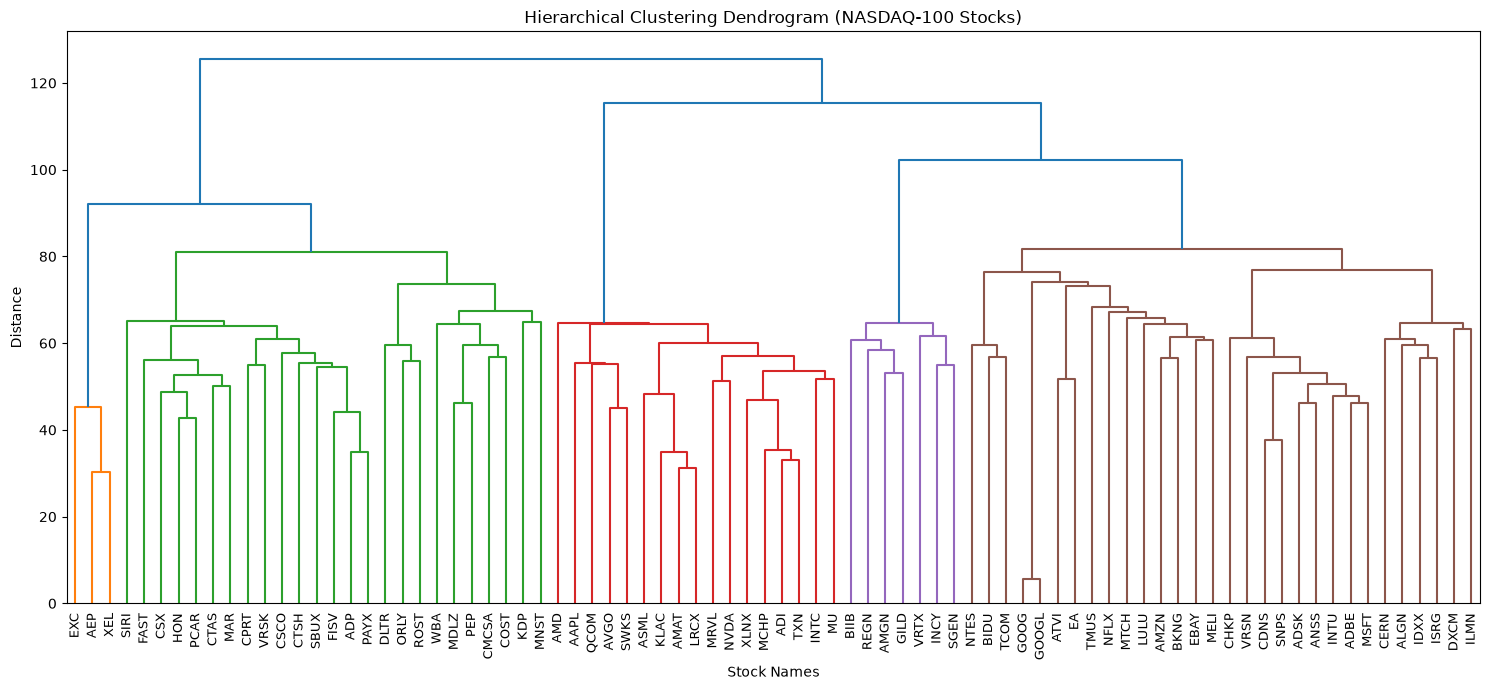

In [108]:
# step 1.1
corr_matrix = clean_returns.corr()

# step 1.2
dist_matrix = np.sqrt(0.5 * (1 - corr_matrix))
dist_vector = ssd.squareform(dist_matrix)

# step 1.3
Z = linkage(X, method='ward') 

# step 2 
plt.figure(figsize=(15, 7))
plt.title("Hierarchical Clustering Dendrogram (NASDAQ-100 Stocks)")
plt.xlabel('Stock Names')
plt.ylabel('Distance')

dendrogram(
    Z, 
    labels=clean_returns.columns.to_list(),
    leaf_rotation=90,
    leaf_font_size=9
)

plt.tight_layout()
plt.show()

In [109]:
# step 3 
max_clusters = 4
cluster = fcluster(Z, t=max_clusters, criterion='maxclust')

# step 4
df_clusters = pd.DataFrame({
    'Stock': stock_names, 
    'Cluster': cluster
})

df_clusters.sort_values(by='Cluster')

print(df_clusters['Cluster'].value_counts())

Cluster
4    30
1    28
2    17
3     7
Name: count, dtype: int64


## AgglomerativeClustering
### กราฟแบบ clean data ธรรมดา

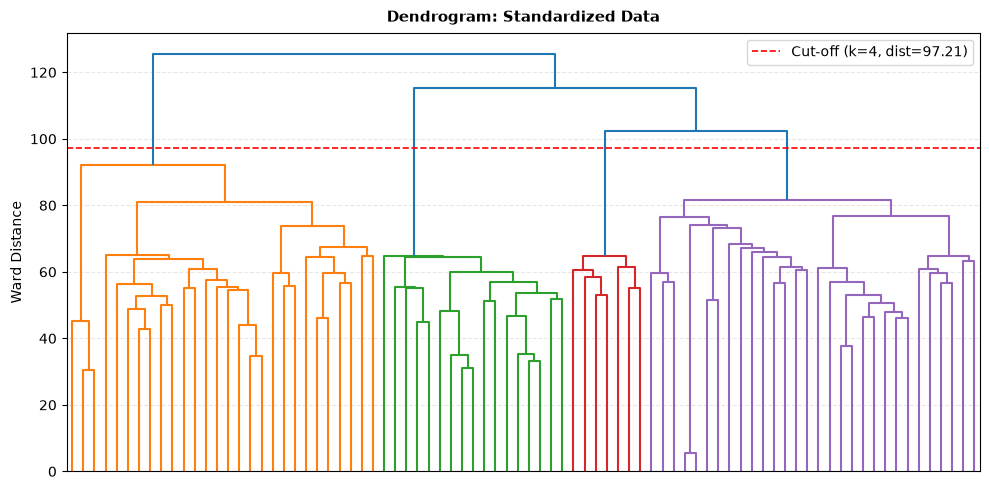

In [110]:
from sklearn.cluster import AgglomerativeClustering

agg_raw = AgglomerativeClustering(n_clusters=3, linkage='ward').fit(X)

fig, axes = plt.subplots(figsize=(10, 5))

Z = linkage(X, method="ward")
thresh = (Z[-3, 2] + Z[-4, 2]) / 2  # ระยะตัดแบ่ง k=4

ax1 = plt.gca()
dendrogram(Z, no_labels=True, color_threshold=thresh, ax=ax1)
ax1.axhline(
    
    thresh,
    color="red",
    linestyle="--",
    linewidth=1.2,
    label=f"Cut-off (k=4, dist={thresh:.2f})",
)
ax1.set_title("Dendrogram: Standardized Data", fontsize=11, fontweight="bold", pad=8)
ax1.set_ylabel("Ward Distance")
ax1.legend(loc="upper right")
ax1.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### graph ที่ผ่านการทำ PCA

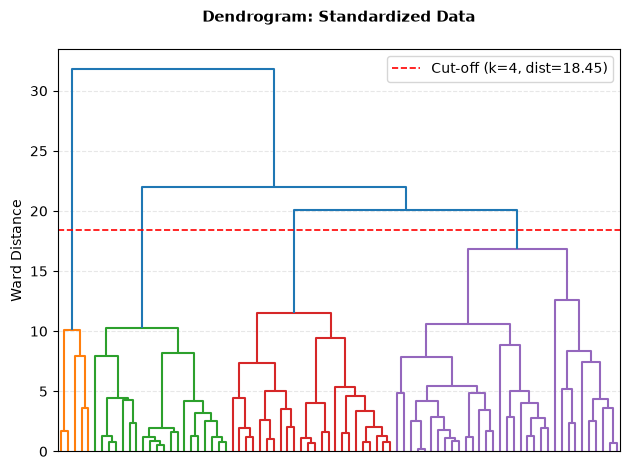

In [111]:
agg_pca = AgglomerativeClustering(n_clusters=4, linkage='ward').fit(pca_features)

Z = linkage(pca_features, method="average")
thresh = (Z[-3, 2] + Z[-4, 2]) / 2  # ระยะตัดแบ่ง k=4

ax1 = plt.gca()
dendrogram(Z, no_labels=True, color_threshold=thresh, ax=ax1)
ax1.axhline(
    
    thresh,
    color="red",
    linestyle="--",
    linewidth=1.2,
    label=f"Cut-off (k=4, dist={thresh:.2f})",
)
ax1.set_title("Dendrogram: Standardized Data", fontsize=11, fontweight="bold", pad=20)
ax1.set_ylabel("Ward Distance")
ax1.legend(loc="upper right")
ax1.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

## การทำ Random Projection

In [112]:
from sklearn.random_projection import GaussianRandomProjection

In [113]:
grp = GaussianRandomProjection(n_components=80, random_state=42)
X_RP = grp.fit_transform(X)

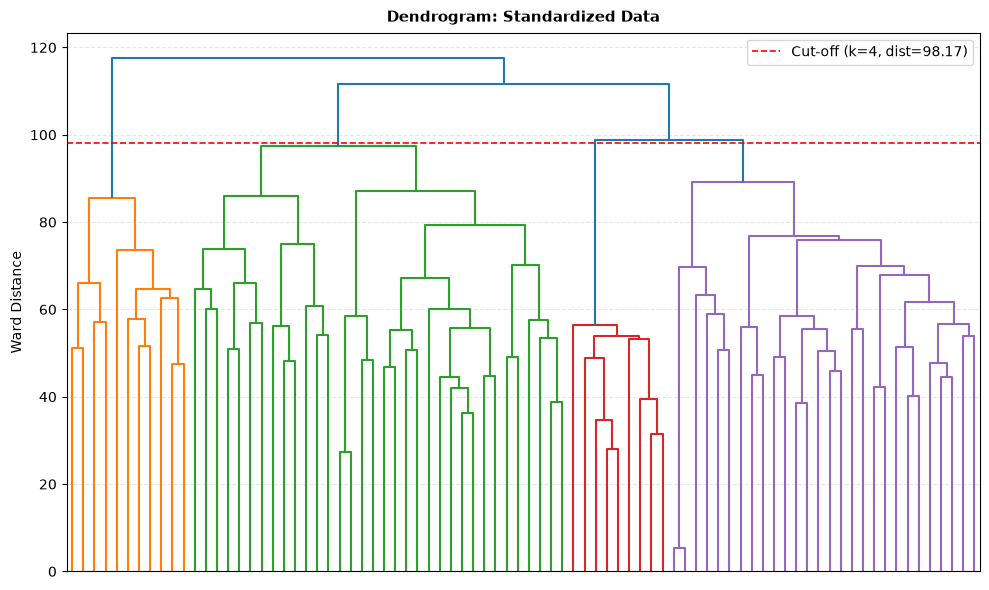

In [114]:
fig, axes = plt.subplots(figsize=(10, 6))

Z = linkage(X_RP, method="ward")
thresh = (Z[-3, 2] + Z[-4, 2]) / 2  # ระยะตัดแบ่ง k=4

ax1 = plt.gca()
dendrogram(Z, no_labels=True, color_threshold=thresh, ax=ax1)
ax1.axhline(
    
    thresh,
    color="red",
    linestyle="--",
    linewidth=1.2,
    label=f"Cut-off (k=4, dist={thresh:.2f})",
)
ax1.set_title("Dendrogram: Standardized Data", fontsize=11, fontweight="bold", pad=8)
ax1.set_ylabel("Ward Distance")
ax1.legend(loc="upper right")
ax1.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

## สรุปหุ้นที่น่าเอาไปลง Port
### ขั้นตอนการทำ
1. คำนวณ Return และ Volatility ของแต่ละหุ้น
2. รวม Cluster Label เข้ากับ Stats
3. สรุปค่าเฉลี่ยแยกตาม Cluster

In [115]:
# step 1 
stock_stats = pd.DataFrame({
    'Mean_Return': clean_returns.mean() * 252, # Annualized Return (ปีละ ~252 วันทำการ)
    'Volatility': clean_returns.std() * np.sqrt(252),
})
stock_stats['Sharpe_Ratio'] = stock_stats['Mean_Return'] / stock_stats['Volatility']

# step 2
df_summary_base = df_clusters.merge(stock_stats, left_on='Stock', right_index=True)

# step 3
cluster_summary = df_summary_base.groupby('Cluster').agg(
    Number_of_Stocks=('Stock', 'count'),
    Avg_Annual_Return=('Mean_Return', 'mean'),
    Avg_Volatility=('Volatility', 'mean'),
    Avg_Sharpe=('Sharpe_Ratio', 'mean')
).reset_index()

print("=== สรุปภาพรวมแยกตาม Cluster ===")
cluster_summary

=== สรุปภาพรวมแยกตาม Cluster ===


,Cluster,Number_of_Stocks,Avg_Annual_Return,Avg_Volatility,Avg_Sharpe
0,1,28,0.161371,0.249839,0.657678
1,2,17,0.208583,0.357580,0.598797
2,3,7,0.172076,0.376695,0.462156
3,4,30,0.221401,0.337343,0.671816


## Visual Summary

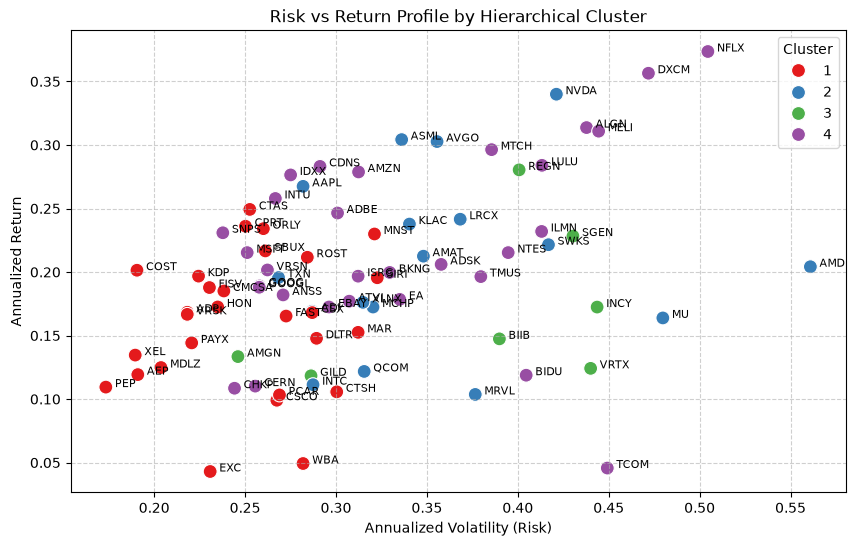

In [116]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_summary_base,
    x='Volatility',
    y='Mean_Return',
    hue='Cluster',
    palette='Set1',
    s=100
)

# ใส่ชื่อหุ้นกำกับจุดในกราฟ (สุ่มใส่บางตัวเพื่อไม่ให้แน่นเกินไป)
for i in range(len(df_summary_base)):
    plt.text(
        df_summary_base['Volatility'].iloc[i] + 0.005, 
        df_summary_base['Mean_Return'].iloc[i], 
        df_summary_base['Stock'].iloc[i], 
        fontsize=8
    )

plt.title('Risk vs Return Profile by Hierarchical Cluster')
plt.xlabel('Annualized Volatility (Risk)')
plt.ylabel('Annualized Return')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## การดูกราฟ
- แกนนอน (Annualized Volatility / Risk): ยิ่งไปทาง ขวา = ความเสี่ยง/ความผันผวน สูง (แกนซ้าย = ความเสี่ยงต่ำ)
- แกนตั้ง (Annualized Return): ยิ่งขึ้นไปทาง บน = ผลตอบแทนเฉลี่ย สูง (แกนล่าง = ผลตอบแทนต่ำ)
#### เมื่อนำ 2 แกนมาตัดกัน จะแบ่งพื้นที่กราฟออกเป็น 4 โซนหลัก:
1. ซ้ายบน (Best): ความเสี่ยงต่ำ แต่ผลตอบแทนสูง (หุ้นปันผลดี/หุ้นแกร่ง)
2. ขวาบน (High Risk, High Return): ความเสี่ยงสูง ผลตอบแทนสูง (หุ้นเติบโตสูง / หุ้นเก็งกำไร)
3. ซ้ายล่าง (Low Risk, Low Return): ความเสี่ยงต่ำ ผลตอบแทนต่ำ (หุ้นตั้งรับ / หุ้นสาธารณูปโภค)
4. ขวาล่าง (Worst): ความเสี่ยงสูง แต่ผลตอบแทนต่ำ (หุ้นผันผวนฟรี / หุ้นขาดทุน)

## สรุปหุ้นจากกราฟ
1. #### Cluster 1 (สีแดง): "Defensive & Low Volatility (กลุ่มความเสี่ยงต่ำ-ปลอดภัย)"
   - คำอธิบาย: หุ้นกลุ่มนี้มีความผันผวนต่ำที่สุดในตลาด (ส่วนใหญ่เป็นหุ้นอุปโภคบริโภค สินค้าจำเป็น และพลังงาน/สาธารณูปโภค) ผลตอบแทนเกาะกลุ่มปานกลางถึงต่ำ เหมาะสำหรับการถือเพื่อลดความเสี่ยงพอร์ต
2. #### Cluster 2 (สีฟ้า): "High Return & Moderate-High Risk (กลุ่มเติบโตสูง)"
   - คำอธิบาย: เป็นกลุ่มหุ้นเซมิคอนดักเตอร์และบิ๊กเทค (Big-Tech / Semiconductor) ที่สร้างผลตอบแทนได้โดดเด่นมาก (0.25 - 0.35) แต่ก็แลกมาด้วยความเสี่ยง/ความผันผวนที่สูงกว่ากลุ่มสีแดง
3. #### Cluster 3 (สีเขียว): "High Risk, Moderate Return / Cyclical (กลุ่มเสี่ยงสูงแต่ตอบแทนปานกลาง)"
   - คำอธิบาย: หุ้นกลุ่มนี้ส่วนใหญ่เป็นหุ้น Healthcare / Biotech หรือ หุ้นผูกกับวัฏจักร (Cyclical) ซึ่งมีข่าวผลการทดลองยาหรือปัจจัยเฉพาะตัวทำให้ราคาผันผวนสูงมาก (Risk สูง) แต่ผลตอบแทนโดยเฉลี่ยไม่ได้สูงตามความเสี่ยง
4. #### Cluster 4 (สีม่วง): "High Volatility / Outliers & High Growth (กลุ่มความเสี่ยงสูง/ผันผวนจัด)"
   - คำอธิบาย: หุ้นกลุ่มนี้มี Variance/Volatility สูงมาก (0.30 - 0.50+) มีทั้งตัวที่ผลตอบแทนพุ่งสูงมากๆ อย่าง NFLX และตัวที่ผันผวนแต่ตอบแทนต่ำอย่าง TCOM

# หุ้นตัวแทนกลุ่ม
- หาหุ้นที่อยู่ใกล้จุดศูนย์กลางของกลุ่มที่สุด

### วิธีทำ
1. รวมผลลัพธ์คลาสเตอริ่งกลับเข้าไปในข้อมูลสเกลแล้ว
2. ดึงดัชนีของหุ้นที่อยู่ใน Cluster c
3. ดึงข้อมูลการเปลี่ยนแปลงราคาของหุ้นในกลุ่มนี้
4. คำนวณจุดศูนย์กลางของกลุ่ม (Mean Vector/Centroid)
5. คำนวณระยะห่าง (Euclidean Distance) ระหว่างหุ้นแต่ละตัวในกลุ่มกับ Centroid
6. หุ้นที่มีระยะห่างน้อยที่สุด คือ Medoid (ตัวแทนกลุ่ม)
7. แสดงผลหุ้นตัวแทนของแต่ละกลุ่ม

In [118]:
representative_stocks = {}
for c in np.unique(cluster):
    # step 2 
    stock_indices = np.where(cluster == c)[0]

    # step 3 
    cluster_X = X[stock_indices]

    # step 4 
    centroid = np.mean(cluster_X, axis=0)

    # step 5 
    distances = np.linalg.norm(cluster_X - centroid, axis=1)

    # step 6 
    best_stock_idx = stock_indices[np.argmin(distances)]
    best_stock_name = stock_names[best_stock_idx]

    representative_stocks[f"Cluster {c}"] = best_stock_name

# step 7 
for clust, stock in representative_stocks.items():
    print(f"ตัวแทนของ {clust} คือ: {stock}")

ตัวแทนของ Cluster 1 คือ: ADP
ตัวแทนของ Cluster 2 คือ: TXN
ตัวแทนของ Cluster 3 คือ: AMGN
ตัวแทนของ Cluster 4 คือ: SNPS
